In [5]:
!pip install pandas numpy scikit-learn matplotlib seaborn


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [7]:
data = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")   # change to your file name

data.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [9]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

print("Cleaned Shape:", data.shape)


Cleaned Shape: (223082, 79)


In [10]:
data[' Label'] = data[' Label'].apply(lambda x: 1 if x == 'BENIGN' else -1)


In [11]:
X = data.drop(' Label', axis=1)
y = data[' Label']


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


In [14]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

model.fit(X_train)


,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [15]:
y_pred = model.predict(X_test)


In [16]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          -1       0.18      0.03      0.05     25663
           1       0.38      0.81      0.52     18954

    accuracy                           0.36     44617
   macro avg       0.28      0.42      0.28     44617
weighted avg       0.26      0.36      0.25     44617



Matplotlib is building the font cache; this may take a moment.


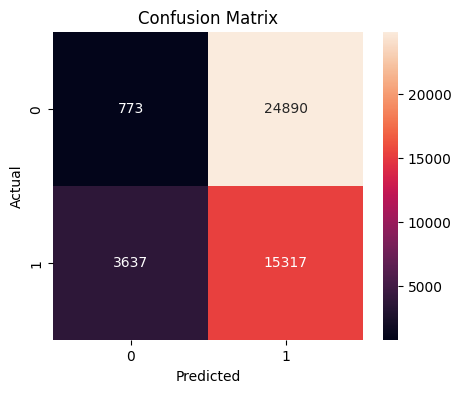

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [18]:
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)


Accuracy: 0.3606248739269785


In [19]:
# Take 10 random samples as new incoming data
new_data = X.sample(10)

# Normalize using trained scaler
new_data_scaled = scaler.transform(new_data)

# Predict anomaly scores
predictions = model.predict(new_data_scaled)
scores = model.decision_function(new_data_scaled)

for i in range(len(predictions)):
    if predictions[i] == 1:
        print("Normal | Score:", scores[i])
    else:
        print("Anomalous | Score:", scores[i])


Normal | Score: 0.09482586225335943
Normal | Score: 0.01706256795094213
Normal | Score: 0.12871843777706826
Normal | Score: 0.1145355837622784
Anomalous | Score: -0.0404128478466087
Normal | Score: 0.13562905617925103
Normal | Score: 0.13923107504209192
Anomalous | Score: -0.04496634337862948
Normal | Score: 0.1561561259081206
Normal | Score: 0.13994634191387617


In [20]:
y_train_rf = (y_train == 1).astype(int)
y_test_rf = (y_test == 1).astype(int)

rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train_rf)

rf_pred = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test_rf, rf_pred))
rf_acc = accuracy_score(y_test_rf, rf_pred)


Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25663
           1       1.00      1.00      1.00     18954

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



In [21]:
X_train_normal = X_train[y_train == 1]


In [22]:
import sys
print(sys.version)


3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]


In [23]:
!pip install tensorflow


In [24]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


In [25]:
# Import required layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Define input dimension
input_dim = X_train.shape[1]

# Build Autoencoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# Train only on normal traffic
X_train_normal = X_train[y_train == 1]

autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.1
)


Epoch 1/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.7319 - val_loss: 0.3496
Epoch 2/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2525 - val_loss: 0.2031
Epoch 3/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1549 - val_loss: 0.1658
Epoch 4/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1152 - val_loss: 0.1196
Epoch 5/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0948 - val_loss: 0.1002
Epoch 6/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0836 - val_loss: 0.0982
Epoch 7/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0738 - val_loss: 0.0838
Epoch 8/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0641 - val_loss: 0.0705
Epoch 9/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0582 - val_loss: 0.0713
Epoch 10/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0525 - val_loss: 0.0711


In [26]:
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

threshold = np.percentile(mse, 95)
ae_pred = [1 if e < threshold else -1 for e in mse]

print("Autoencoder Results")
print(classification_report(y_test, ae_pred))
ae_acc = accuracy_score(y_test, ae_pred)


1395/1395 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Autoencoder Results
              precision    recall  f1-score   support

          -1       0.96      0.08      0.15     25663
           1       0.45      1.00      0.62     18954

    accuracy                           0.47     44617
   macro avg       0.70      0.54      0.38     44617
weighted avg       0.74      0.47      0.35     44617



In [34]:
# Isolation Forest prediction
iso_pred = iso_model.predict(X_test)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

# Random Forest prediction
rf_pred = rf_model.predict(X_test)

# Autoencoder prediction (example)
reconstructions = autoencoder.predict(X_test)
import numpy as np
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)
threshold = np.percentile(mse, 95)
ae_pred = [1 if e > threshold else 0 for e in mse]

1395/1395 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [36]:
# Get reconstruction predictions first
reconstructions = autoencoder.predict(X_test)

# Compute reconstruction error
import numpy as np
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

# Set threshold (example)
threshold = np.percentile(mse, 95)

# Convert to binary prediction
ae_pred = [1 if e > threshold else 0 for e in mse]

1395/1395 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [37]:
from sklearn.metrics import accuracy_score

iso_acc = accuracy_score(y_test, iso_pred)
rf_acc = accuracy_score(y_test, rf_pred)
ae_acc = accuracy_score(y_test, ae_pred)

print(iso_acc, rf_acc, ae_acc)

0.10045498352645853 0.9999103480736042 0.0018378644911132527


In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Isolation Forest", "Random Forest", "Autoencoder"],
    "Accuracy": [iso_acc, rf_acc, ae_acc]
})

print(results)

              Model  Accuracy
0  Isolation Forest  0.100455
1     Random Forest  0.999910
2       Autoencoder  0.001838


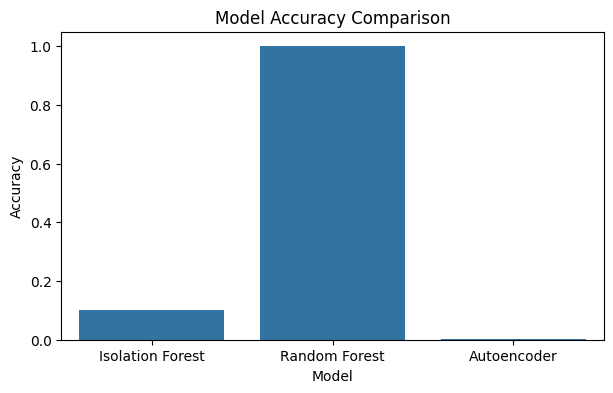

In [39]:
plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.show()


In [41]:
iso_model = IsolationForest(random_state=42)
iso_model.fit(X_train)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [42]:
predictions = iso_model.predict(sample_scaled)

In [43]:
sample = X.sample(5)
sample_scaled = scaler.transform(sample)

predictions = iso_model.predict(sample_scaled)

for p in predictions:
    if p == 1:
        print("Normal Traffic")
    else:
        print("Anomalous Traffic")

Anomalous Traffic
Normal Traffic
Normal Traffic
Normal Traffic
Normal Traffic


In [44]:
reconstructions = autoencoder.predict(X_test)


1395/1395 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [46]:
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)


In [47]:
train_reconstructions = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_reconstructions, 2), axis=1)

threshold = np.percentile(train_mse, 95)
print("Threshold:", threshold)


2379/2379 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Threshold: 0.12955715602159998


In [48]:
ae_pred = np.where(mse > threshold, -1, 1)


In [49]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, ae_pred))
print("Accuracy:", accuracy_score(y_test, ae_pred))


              precision    recall  f1-score   support

          -1       0.95      0.64      0.76     25663
           1       0.66      0.95      0.78     18954

    accuracy                           0.77     44617
   macro avg       0.80      0.79      0.77     44617
weighted avg       0.82      0.77      0.77     44617

Accuracy: 0.770020395813255


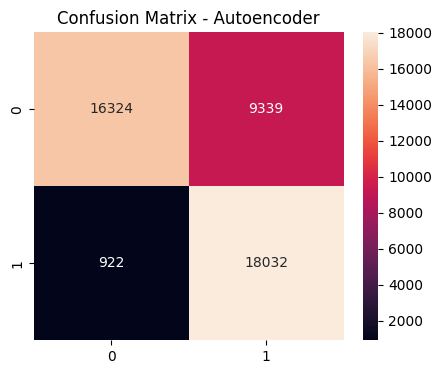

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ae_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Autoencoder")
plt.show()


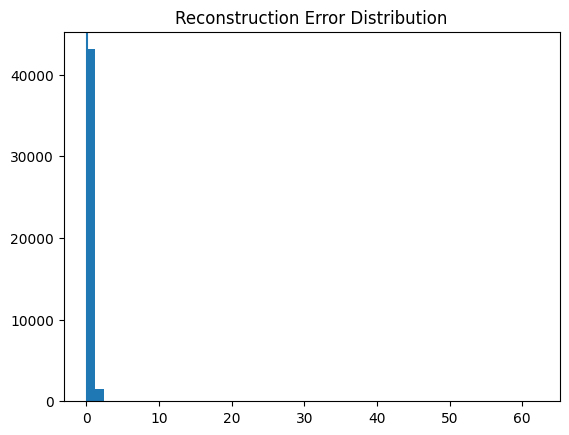

In [51]:
plt.hist(mse, bins=50)
plt.axvline(threshold)
plt.title("Reconstruction Error Distribution")
plt.show()


In [52]:
results = pd.DataFrame({
    "Model": ["Isolation Forest", "Random Forest", "Autoencoder"],
    "Accuracy": [iso_acc, rf_acc, ae_acc]
})

print(results)


              Model  Accuracy
0  Isolation Forest  0.100455
1     Random Forest  0.999910
2       Autoencoder  0.001838
